# Medical Image Segmentation using U-Net and Stacked U-Net

This notebook follows a medical-style workflow:
- Load one medical image and one mask
- Train `UNet` and `StackedUNet`
- Show: original image, ground truth, base U-Net prediction, stacked U-Net prediction

If no mask file is available, a pseudo-mask is created automatically so the notebook can still run.

In [3]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image

# ---------------- SETTINGS ----------------
EPOCHS = 30
SIZE = 256
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# You can change these to your own files
IMG_PATH = r"c:\Users\praan\Desktop\pvlab\lab4\medical_images\medical_image1.jpg"
MASK_PATH = r"c:\Users\praan\Desktop\pvlab\lab4\medical_images\medical_image1_mask.png"

Device: cpu


In [4]:
# ---------------- LOAD IMAGE + MASK ----------------
img = Image.open(IMG_PATH).convert("L").resize((SIZE, SIZE))
img_np = np.array(img, dtype=np.float32) / 255.0

if os.path.exists(MASK_PATH):
    mask = Image.open(MASK_PATH).convert("L").resize((SIZE, SIZE))
    mask_np = (np.array(mask, dtype=np.float32) > 127).astype(np.float32)
    print("Mask loaded from file.")
else:
    # Fallback pseudo-mask (for demo only)
    blur = cv2.GaussianBlur((img_np * 255).astype(np.uint8), (5, 5), 0)
    _, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask_np = (otsu > 0).astype(np.float32)
    print("Mask file not found. Using auto-generated pseudo-mask for demo.")

img_t = torch.tensor(img_np).unsqueeze(0).unsqueeze(0).to(device)   # [1,1,H,W]
mask_t = torch.tensor(mask_np).unsqueeze(0).unsqueeze(0).to(device) # [1,1,H,W]

print("Image tensor:", tuple(img_t.shape))
print("Mask tensor:", tuple(mask_t.shape))

Mask file not found. Using auto-generated pseudo-mask for demo.
Image tensor: (1, 1, 256, 256)
Mask tensor: (1, 1, 256, 256)


In [5]:
# ---------------- MODEL BLOCKS ----------------
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.seq(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(1, 64)
        self.d2 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def crop(self, enc, dec):
        _, _, h, w = dec.shape
        return enc[:, :, :h, :w]

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.pool(d1))

        bridge = self.bridge(self.pool(d2))

        u1 = self.up1(bridge)
        d2 = self.crop(d2, u1)
        u1 = self.c1(torch.cat([u1, d2], 1))

        u2 = self.up2(u1)
        d1 = self.crop(d1, u2)
        u2 = self.c2(torch.cat([u2, d1], 1))

        return torch.sigmoid(self.out(u2))


class StackedUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet1 = UNet()
        self.unet2 = UNet()

    def forward(self, x):
        p1 = self.unet1(x)
        p2 = self.unet2(x * p1)
        return p1, p2

In [6]:
# ---------------- TRAIN ----------------
model = StackedUNet().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

print("Training...")
model.train()
for e in range(EPOCHS):
    p1, p2 = model(img_t)
    loss = loss_fn(p1, mask_t) + loss_fn(p2, mask_t)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if e % 5 == 0:
        print(f"Epoch {e:02d} | Loss: {loss.item():.6f}")

Training...
Epoch 00 | Loss: 1.387336
Epoch 05 | Loss: 1.188414
Epoch 10 | Loss: 0.725508
Epoch 15 | Loss: 0.289265
Epoch 20 | Loss: 0.166133
Epoch 25 | Loss: 0.152571


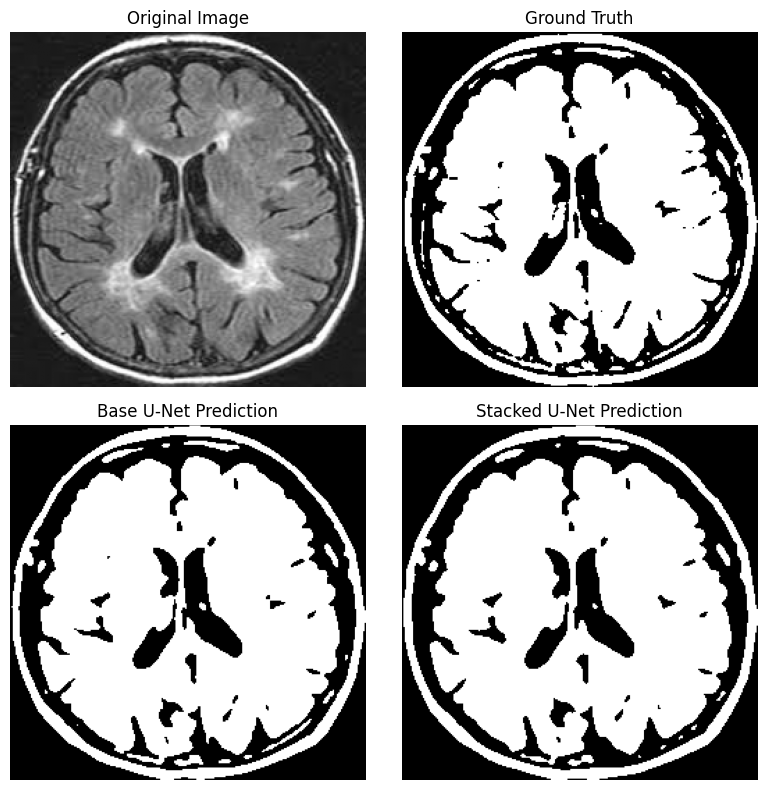

In [7]:
# ---------------- PREDICT + SHOW ----------------
model.eval()
with torch.no_grad():
    p1, p2 = model(img_t)

p1_bin = (p1.squeeze().cpu().numpy() > 0.5).astype(np.float32)
p2_bin = (p2.squeeze().cpu().numpy() > 0.5).astype(np.float32)
img_show = img_t.squeeze().cpu().numpy()
mask_show = mask_t.squeeze().cpu().numpy()

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img_show, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Ground Truth")
plt.imshow(mask_show, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Base U-Net Prediction")
plt.imshow(p1_bin, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Stacked U-Net Prediction")
plt.imshow(p2_bin, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()